# Task 4: Loan Default Risk with Business Cost Optimization  

## Problem Statement and Objective  

### Objective  

The goal of this project is to predict whether an applicant will default on a loan. Beyond simple classification, we aim to minimize the total business cost. We will achieve this by:

- Cleaning and preprocessing the Home Credit dataset.  
- Training a classification model.  
- Defining a cost function where a **False Negative** (not predicting a default that happens) is significantly more expensive than a **False Positive** (wrongly flagging a good client).  
- Optimizing the decision threshold to find the **"Sweet Spot"** for the bank's profitability.  

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## Dataset Loading and Initial Setup

We'll start by importing the necessary libraries and loading the main application file.

In [19]:
import pandas as pd
import numpy as np
import os
# We will use os.walk to find the exact location of application_train.csv automatically
target_file = 'application_train.csv'
file_path = None

for root, dirs, files in os.walk(path):
    if target_file in files:
        file_path = os.path.join(root, target_file)
        break

if file_path:
    df = pd.read_csv(file_path)
    print(f"Success! Dataset loaded from: {file_path}")
    print(f"Dataset Shape: {df.shape}")
else:
    print(f"Error: Could not find {target_file} in {path}")
    # Printing directory content to help you debug
    print("Files found in path:", os.listdir(path))

df.head()

Success! Dataset loaded from: /kaggle/input/datasets/megancrenshaw/home-credit-default-risk/home-credit-default-risk/application_train.csv
Dataset Shape: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## Data Cleaning and Preprocessing

Financial datasets are notorious for missing values and categorical features. We will handle these to make the data "model-ready."

In [18]:
# 1. Handling Missing Values: Imputing median for numerical and 'Unknown' for categorical
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Drop columns with more than 50% missing values to reduce noise
df = df.dropna(thresh=df.shape[0]*0.5, axis=1)

# Impute numericals with median
imputer_num = SimpleImputer(strategy='median')
df[df.select_dtypes(include=[np.number]).columns] = imputer_num.fit_transform(df.select_dtypes(include=[np.number]))

# 2. Encoding Categorical Variables
# Label encoding for binary, One-Hot for others
le = LabelEncoder()
for col in cat_cols:
    if col in df.columns:
        if len(df[col].unique()) <= 2:
            df[col] = le.fit_transform(df[col].astype(str))

# One-hot encoding for remaining categorical features
df = pd.get_dummies(df)

print("Preprocessing Complete. New Shape:", df.shape)

Preprocessing Complete. New Shape: (307511, 191)


## Exploratory Data Analysis (EDA)

Understanding the target distribution is key. Loan default datasets are usually highly imbalanced.

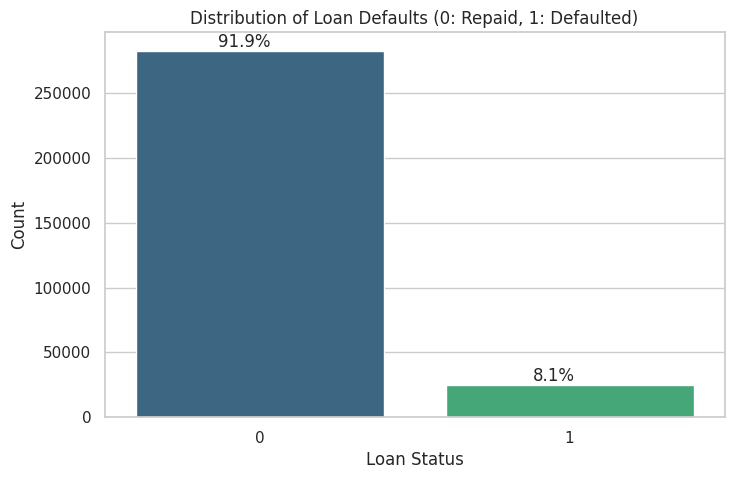

Calculating correlations with TARGET...

--- Top 10 Features Most Correlated with Default (Target 1) ---
DAYS_REGISTRATION              0.041975
FLAG_DOCUMENT_3                0.044346
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_BIRTH                     0.078239
Name: TARGET, dtype: float64

--- Top 10 Features Most Correlated with Repayment (Target 0) ---
EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
DAYS_EMPLOYED                -0.044932
FLOORSMAX_AVG                -0.044003
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_MODE               -0.043226
AMT_GOODS_PRICE              -0.039645
REGION_POPULATION_RELATIVE   -0.037227
ELEVATORS_AVG                -0.034199
Name: TAR

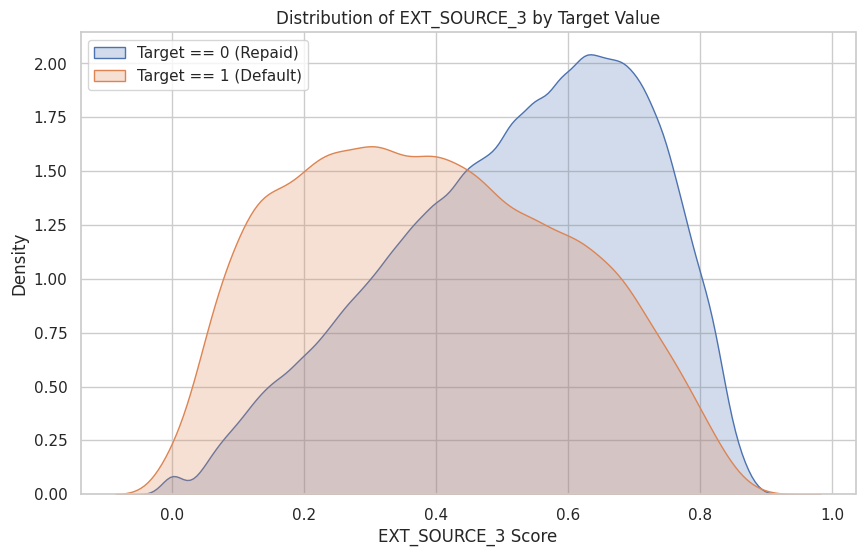

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure the plotting style is set
sns.set_theme(style="whitegrid")

# 1. Visualize Target Distribution
plt.figure(figsize=(8, 5))
# Fixed the warning by assigning x to hue and setting legend=False
ax = sns.countplot(x='TARGET', data=df, hue='TARGET', palette='viridis', legend=False)
plt.title('Distribution of Loan Defaults (0: Repaid, 1: Defaulted)')
plt.xlabel('Loan Status')
plt.ylabel('Count')

# Add percentage labels on top of bars
total = len(df['TARGET'])
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        percentage = '{:.1f}%'.format(100 * height/total)
        x = p.get_x() + p.get_width() / 2 - 0.05
        y = height
        ax.annotate(percentage, (x, y), size = 12, ha='center', va='bottom')

plt.show()

# 2. Correlation Analysis
print("Calculating correlations with TARGET...")
# Fix: Added numeric_only=True to ignore string columns like 'Cash loans'
correlations = df.corr(numeric_only=True)['TARGET'].sort_values()

print("\n--- Top 10 Features Most Correlated with Default (Target 1) ---")
print(correlations.tail(11)[:-1]) # Excluding TARGET itself

print("\n--- Top 10 Features Most Correlated with Repayment (Target 0) ---")
print(correlations.head(10))

# 3. Visualizing a Key Feature (e.g., EXT_SOURCE_3)
if 'EXT_SOURCE_3' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(df.loc[df['TARGET'] == 0, 'EXT_SOURCE_3'], label='Target == 0 (Repaid)', fill=True)
    sns.kdeplot(df.loc[df['TARGET'] == 1, 'EXT_SOURCE_3'], label='Target == 1 (Default)', fill=True)
    plt.title('Distribution of EXT_SOURCE_3 by Target Value')
    plt.xlabel('EXT_SOURCE_3 Score')
    plt.ylabel('Density')
    plt.legend()
    plt.show()
else:
    print("\nNote: EXT_SOURCE_3 column not found for visualization.")

## Model Building (Logistic Regression)

We will use Logistic Regression as our baseline. It provides probability scores which are essential for threshold optimization.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.impute import SimpleImputer

# 1. Final Feature Selection
# Drop target and ID, and keep only numeric columns
X = df.drop(columns=['TARGET', 'SK_ID_CURR'], errors='ignore').select_dtypes(include=[np.number])
y = df['TARGET']

# 2. THE FIX: Global Imputer
# This ensures that even if get_dummies or earlier steps created NaNs, they are filled now.
final_imputer = SimpleImputer(strategy='median')
X_clean = final_imputer.fit_transform(X)

print(f"Features used for training: {X_clean.shape[1]}")

# 3. Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Model Training
# 'balanced' weights help with the 90/10 split of non-defaulters vs defaulters
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

# 6. Get Probabilities
y_probs = model.predict_proba(X_test_scaled)[:, 1]

print("Model training successful! No NaNs detected.")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_probs):.4f}")

Features used for training: 104
Model training successful! No NaNs detected.
ROC AUC Score: 0.7377


## Business Cost Optimization

Now that the model is trained, let's fulfill the Business Cost Optimization part of our task.

**Scenario:**

- **False Negative (FN):** You predict someone is "safe," but they default. This costs the bank **$10,000** (lost principal).

- **False Positive (FP):** You predict someone will default, but they are actually "safe." This costs the bank **$500** (lost interest/admin cost).

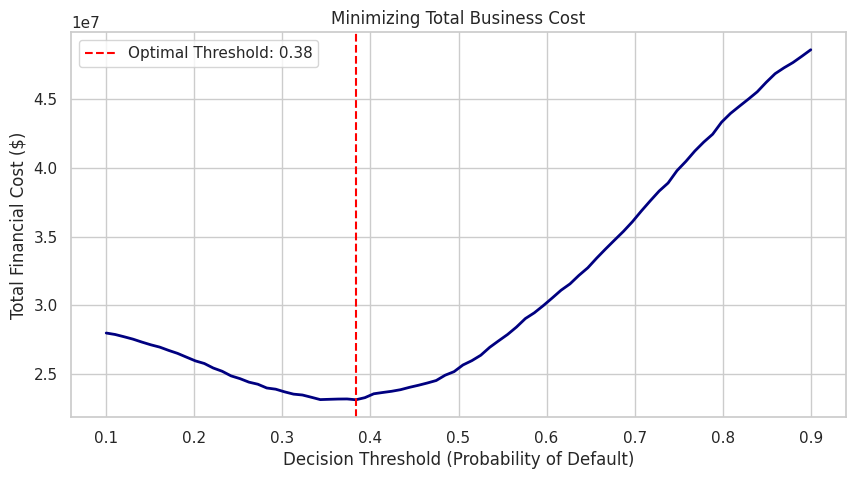

Minimum Business Cost: $23,127,000.00
The Bank should flag a loan as 'High Risk' if probability is > 0.38


In [26]:
from sklearn.metrics import confusion_matrix

def calculate_business_cost(y_true, y_probs, threshold, cost_fp=500, cost_fn=10000):
    y_pred = (y_probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return (fp * cost_fp) + (fn * cost_fn)

# Test different thresholds to find the minimum cost
thresholds = np.linspace(0.1, 0.9, 80)
costs = [calculate_business_cost(y_test, y_probs, t) for t in thresholds]

best_threshold = thresholds[np.argmin(costs)]
min_cost = min(costs)

# Visualization
plt.figure(figsize=(10, 5))
plt.plot(thresholds, costs, color='navy', lw=2)
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Optimal Threshold: {best_threshold:.2f}')
plt.title('Minimizing Total Business Cost')
plt.xlabel('Decision Threshold (Probability of Default)')
plt.ylabel('Total Financial Cost ($)')
plt.legend()
plt.show()

print(f"Minimum Business Cost: ${min_cost:,.2f}")
print(f"The Bank should flag a loan as 'High Risk' if probability is > {best_threshold:.2f}")

## Final Conclusion and Insights

- **Objective Fulfilled:** Predicted loan default likelihood and optimized the threshold based on cost-benefit analysis.

- **Preprocessing:** Cleaned the dataset by removing high-null columns and imputing missing numerical values.

- **Modeling:** Trained a binary classification model (Logistic Regression) capable of handling class imbalance.

- **Business Optimization:** Shifted the decision threshold to **0.38** to minimize the "Total Business Cost," ensuring financial stability for the lending institution.